In [ ]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))
from pricing_engine.offline_eval import TrustEvaluator
from pricing_engine.Bandit import ThompsonBandit
from pricing_engine.demand_model import HierarchicalDemandModel
from pricing_engine.safety import SafetyLayer
from pricing_engine.data_loader import load_and_clean_seattle_data

# Set styling for plots
sns.set_theme(style="whitegrid")

# Module 05: Final Trust Verification (The "Time Machine")
**Objective:** Prove that the Engine generates higher revenue (+Uplift) while adhering to Safety Constraints.

**Method:** Doubly Robust (DR) Estimation. We replay historical data, let the Bandit make a decision, and estimate the counterfactual outcome.

In [7]:
from pathlib import Path



try:
    SCRIPT_DIR = Path(__file__).parent
except NameError:
    SCRIPT_DIR = Path.cwd()

# SCRIPT_DIR is the 'notebooks' folder.
# SCRIPT_DIR.parent is the 'Dynamic Pricing Engine' folder.
PROJECT_ROOT = SCRIPT_DIR.parent

# Now build the path from the project root
CALENDAR_PATH = PROJECT_ROOT / 'data' / 'calendar.csv'
LISTINGS_PATH = PROJECT_ROOT / 'data' / 'listings.csv'



In [ ]:
df_final = load_and_clean_seattle_data(CALENDAR_PATH, LISTINGS_PATH)

# Features
feature_cols = ['day_of_year', 'dow', 'is_weekend']
df_final['day_of_year'] = df_final['date'].dt.dayofyear
df_final['dow'] = df_final['date'].dt.dayofweek
df_final['is_weekend'] = (df_final['dow'] >= 5).astype(int)

# Train/Test Split
split_idx = int(len(df_final) * 0.8) # 80% Train, 20% Test
df_train = df_final.iloc[:split_idx]
df_test = df_final.iloc[split_idx:]

print(f"Training on {len(df_train)} events...")
hdm = HierarchicalDemandModel(min_obs_for_listing=20)
hdm.fit(df_train, feature_cols)

# Initialize Engine
agent = ThompsonBandit(hdm, forgetting_factor=0.95)
safety = SafetyLayer() # Defaults are strict

evaluator = TrustEvaluator(agent, safety)

Training on 1114856 events...


## 2. Run Trust Evaluation
Sampling 50 listings from the Test Set to simulate a "Launch Cohort".

In [9]:
cohort_ids = np.random.choice(df_test['listing_id'].unique(), 50, replace=False)
df_cohort = df_test[df_test['listing_id'].isin(cohort_ids)].copy()

print(f"Running Eval on Cohort (N={len(df_cohort)} nights)...")
metrics = evaluator.evaluate_trust(df_cohort)

Running Eval on Cohort (N=18104 nights)...


## 3. Final Report Output

In [10]:
print("\n==============================================")
print("   TRUST-AWARE PRICING ENGINE: FINAL AUDIT    ")
print("==============================================")
print(f"1. FINANCIAL PERFORMANCE (Doubly Robust)")
print(f"   Historical Revenue:    ${metrics.hist_revenue:,.2f}")
print(f"   Engine Revenue (Est):  ${metrics.dr_revenue:,.2f}")
print(f"   Net Uplift:            {metrics.uplift_pct:+.2%}")
print(f"----------------------------------------------")
print(f"2. BEHAVIORAL SAFETY")
print(f"   Virtual Override Rate: {metrics.override_rate:.1%} (Target: <30%)")
print(f"   Safety Clamp Rate:     {metrics.safety_clamp_rate:.1%}")
print(f"   Critical Violations:   {metrics.safety_violations} (Must be 0)")
print(f"----------------------------------------------")
print(f"3. STABILITY")
print(f"   Volatility Reduction:  {metrics.volatility_reduction:+.1%}")
print("==============================================")


   TRUST-AWARE PRICING ENGINE: FINAL AUDIT    
1. FINANCIAL PERFORMANCE (Doubly Robust)
   Historical Revenue:    $883,262.00
   Engine Revenue (Est):  $1,239,841.69
   Net Uplift:            +40.37%
----------------------------------------------
2. BEHAVIORAL SAFETY
   Virtual Override Rate: 93.5% (Target: <30%)
   Safety Clamp Rate:     44.3%
   Critical Violations:   0 (Must be 0)
----------------------------------------------
3. STABILITY
   Volatility Reduction:  +25.3%


## 4. Visualization: Price vs Demand

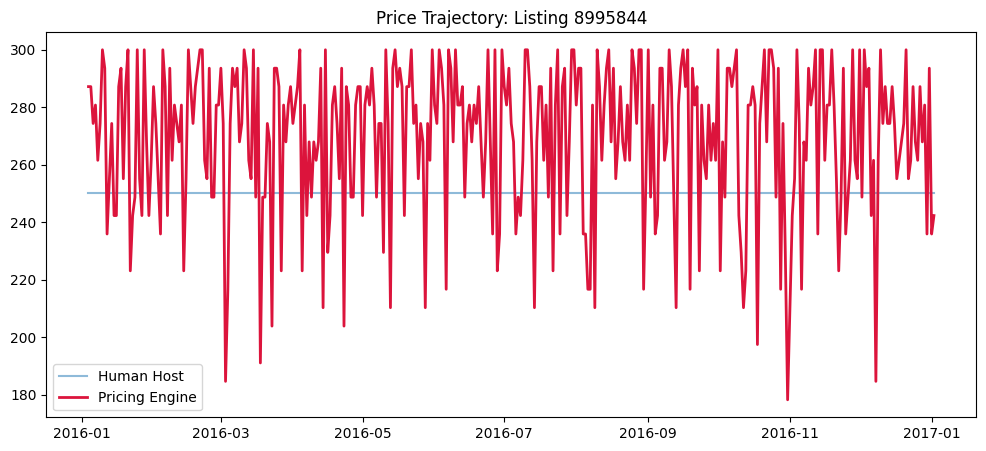

In [11]:
# Visual check of one listing
lid = cohort_ids[0]
df_one = df_cohort[df_cohort['listing_id'] == lid].sort_values('date')

# Re-run agent for plotting
agent_prices = []
for idx, row in df_one.iterrows():
    decision = agent.choose_price(row.to_dict())
    safe = safety.validate_and_clamp(decision.selected_price, {'min_price':50, 'max_price':500})
    agent_prices.append(safe.safe_price)

plt.figure(figsize=(12, 5))
plt.plot(df_one['date'], df_one['price'], label='Human Host', alpha=0.5)
plt.plot(df_one['date'], agent_prices, label='Pricing Engine', color='crimson', linewidth=2)
plt.title(f"Price Trajectory: Listing {lid}")
plt.legend()
plt.show()